### This is a simple/fast tutorial for creating experiments

In [1]:
from scheduling_functions import *
from scheduling_algorithms import *
import numpy as np
import sys
import copy
from random import sample, randint, seed
from math import isclose, ceil, floor
from statistics import mean
from decimal import *
from fractions import *
import matplotlib.pyplot as plt
from operator import add

## General instructions/restrictions
1. Usually job instances are denoted by J_something. They are python dictionaries in which every element is a tuple (job_weight, release_time, deadline). By convention we will refer to the job that arrives at time t as the job with id (key in the dictionary representation) t+1.

2. __Job weights should be integers >=0__.

3. The robustness parameter epsilon should be rational, e.g. epsilon = Fraction(1,10). Most internal operations in the scheduling libraries use the __fraction module__ to avoid errors due to arithmetic precision.

4. To create a job instance easily, use the job_instance_creation function, the inputs should be a weights list, and D. The i-th element of the weights list (ws[i-1]) represents the job which is released at time i-1.

5. To create a bounded random walk as described in the paper, use random_walk_creation

6. The functions __AVR_energy_ratio__, __OA_energy_ratio__, __BKP_energy_ratio__ and __LAS_energy_ratio__ take as input a job instance as described before and give as output the competitive ratios of the respective algorithms.

In [2]:
#creates a bounded random walk:

def random_walk_creation(num_jobs, step_size, random_seed, m, M):
    seed(random_seed)

    ws = [0]*num_jobs
    ws[0] = randint(m,M)
    steps = [randint(-step_size,step_size) for i in range(1,num_jobs)]
    for i in range(1, num_jobs):
        ws[i] = ws[i-1] + steps[i-1]
        ws[i] = min(ws[i], M)
        ws[i] = max(ws[i], m)
    return ws


In [3]:
#creates a job instance given a list of weights and T

def job_instance_creation(ws, T):
    # dictionary: key --> job id
    #            value --> (weight, release time , deadline)
    J = {}
    job_id = 1
    i = 0
    for job_weight in ws:
        J[job_id] = (job_weight , i, i+T)
        i+=1
        job_id+=1
    return J

In [4]:

#returns the energy ratio AVR_energy/Optimal_energy

def AVR_energy_ratio(_J, alpha):
    
    J = copy.deepcopy(_J)
    #speed list of average rate
    AVR_speed_list = Avg_rate(J)
    #energy consumption of AVR
    energy_AVR = compute_energy(AVR_speed_list, alpha)
    
    J = copy.deepcopy(_J)
    #speed list of the optimal schedule
    optimal_alg_speed_list, _ = Optimal_Alg(J)
    #energy consumption of the optimal schedule
    energy_optimal = compute_energy(optimal_alg_speed_list, alpha)  
    
    return float(energy_AVR)/energy_optimal    


In [5]:
#returns the energy ratio OA_energy/Optimal_energy

def OA_energy_ratio(_J, alpha):
    
    J = copy.deepcopy(_J)
    #speed list of Optimal Available
    OA_speed_list = OptimalOnline(J)
    #energy consumption of Optimal Available
    energy_OA = sum([s**alpha for s in OA_speed_list])
    
    J = copy.deepcopy(_J)
    #speed list of the optimal schedule
    optimal_alg_speed_list, _ = Optimal_Alg(J)
    #energy consumption of the optimal schedule
    energy_optimal = compute_energy(optimal_alg_speed_list, alpha)    
   
    return float(energy_OA)/energy_optimal


In [6]:
#returns the energy ratio BKP_energy/Optimal_energy

def BKP_energy_ratio(_J, granularity, alpha):
    
    J = copy.deepcopy(_J)
    #energy consumption of the BKP algorithm
    energy_BKP = BKP_alg(J, granularity, alpha)

    J = copy.deepcopy(_J)
    #speed list of the optimal schedule
    optimal_alg_speed_list, _ = Optimal_Alg(J)
    #energy consumption of the optimal schedule
    energy_optimal = compute_energy(optimal_alg_speed_list, alpha)  
    
    return float(energy_BKP)/energy_optimal 

In [7]:
#returns the energy ratio LAS_energy/Optimal_energy

def LAS_energy_ratio(_J_true, _J_pred, epsilon, alpha, dt):
    
    #compute energy of LAS algorithm
    J_true = copy.deepcopy(_J_true)
    J_pred = copy.deepcopy(_J_pred)
    
    speed_sol = LAS(J_pred, J_true, epsilon, dt, alpha)
    
    
    energy_LAS = sum([s**alpha for s in speed_sol])*dt
    
   
    #compute speedlist and energu consumption of the optimal schedule of the true instance
    J_true = copy.deepcopy(_J_true)
    J_pred = copy.deepcopy(_J_pred)
    optimal_alg_speed_list, _ = Optimal_Alg(J_true)
    energy_optimal = compute_energy(optimal_alg_speed_list, alpha)
    
    return float(energy_LAS)/energy_optimal   

### First experiment

#### parameters setting

In [8]:
num_jobs = 80
D = 10
alpha = 3
epsilon = Fraction(1,20)
dt = 0.01
bkp_granularity = 0.25

#### we create a random ground truth instance

In [9]:
w_min = 10
w_max = 100
w_true = [randint(w_min,w_max) for _ in range(0,num_jobs)]
J_true = job_instance_creation(w_true, D)

#### we create a very accurate predictor by adding pointwise a small integer error between [-3,3]

In [10]:
s = 3
error = [randint(-s,s) for _ in range(0,num_jobs)]
w_pred = list(map(add,w_true, error))
J_pred = job_instance_creation(w_pred, D)

#### now we will calculate the competitive ratio of the online algorithms AVR, OA and BKP

In [11]:
AVR = AVR_energy_ratio(J_true, alpha)
print("AVR competitive ratio: ", AVR)

AVR competitive ratio:  1.1905766841755008


In [12]:
OA = OA_energy_ratio(J_true, alpha)
print("OA competitive ratio: ", OA)

OA competitive ratio:  1.1287940454040155


In [13]:
BKP = BKP_energy_ratio(J_true, bkp_granularity, alpha)
print("BKP competitive ratio: ", BKP)

BKP competitive ratio:  6.995454078952423


#### now we will calculate the competitive ratio of LAS algorithm with $\epsilon = 1/20$

In [14]:
LAS_ratio = LAS_energy_ratio(J_true, J_pred, epsilon, alpha, dt)
print("LAS competitive ratio: ", LAS_ratio)

LAS competitive ratio:  1.0032726262719953


#### we will repeat the experiment by using a perfect predictor and LAS algorithm with $\epsilon = 1/20$

In [15]:
LAS_ratio = LAS_energy_ratio(J_true, J_true, epsilon, alpha, dt)
print("LAS competitive ratio: ", LAS_ratio)

LAS competitive ratio:  1.0012833228926148


### Second experiment

#### we will create an instance which mimics a bounded random walk and an accurate predictor

In [16]:
M = 100
m = 10
random_seed = 10
step_size = 10
s = 10
w_true = random_walk_creation(num_jobs, step_size, random_seed, m, M)
J_true = job_instance_creation(w_true, D)
error = [randint(-s,s) for _ in range(0,num_jobs)]
w_pred = list(map(add,w_true, error))
J_pred = job_instance_creation(w_pred, D)

#### we will plot the weights of the true and the predicted instance

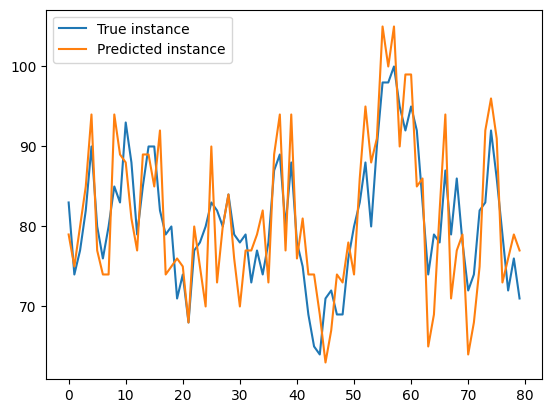

In [17]:
x = range(0, num_jobs)
plt.plot(x, w_true, label = "True instance")
plt.plot(x, w_pred, label = "Predicted instance")
plt.legend(loc="upper left")
plt.show()

#### performance of LAS with $\epsilon = 1/20$

In [18]:
LAS_ratio = LAS_energy_ratio(J_true, J_pred, epsilon, alpha, dt)
print("LAS competitive ratio: ", LAS_ratio)

LAS competitive ratio:  1.006294967413903


In [19]:
def generate_massive_noises(w_true,D,noise_level):
    error = [randint(-noise_level, noise_level) for _ in range(len(w_true))]
    w_pred = [max(0, w + e) for w, e in zip(w_true, error)]
    return job_instance_creation(w_pred, D), w_pred

In [20]:
print("--- Testing the massive noises ---")

--- Testing the massive noises ---


In [21]:
J_pred_bad, w_pred_bad = generate_massive_noises(w_true, D,500)

In [22]:
las_ratio = LAS_energy_ratio(J_true, J_pred_bad, epsilon, alpha, dt)
print(f"LAS Competitive Ratio with TERRIBLE prediction: {las_ratio:.4f}")

LAS Competitive Ratio with TERRIBLE prediction: 1.6873


In [23]:
def generate_blind_prediction(num_jobs, D):
    w_pred = [1] * num_jobs
    return job_instance_creation(w_pred, D), w_pred

In [24]:
J_pred_bad, w_pred_bad = generate_blind_prediction(num_jobs,D)

In [25]:
las_ratio = LAS_energy_ratio(J_true, J_pred_bad, epsilon, alpha, dt)
print(f"LAS Competitive Ratio with TERRIBLE prediction: {las_ratio:.4f}")

LAS Competitive Ratio with TERRIBLE prediction: 1.1783


In [26]:
def generate_inverted_prediction(w_true, D):
    max_w = max(w_true)
    min_w = min(w_true)
    w_pred = [max_w - (w - min_w) for w in w_true]
    return job_instance_creation(w_pred, D), w_pred

In [27]:
J_pred_bad, w_pred_bad = generate_inverted_prediction(w_true, D)

In [28]:
las_ratio = LAS_energy_ratio(J_true, J_pred_bad, epsilon, alpha, dt)
print(f"LAS Competitive Ratio with TERRIBLE prediction: {las_ratio:.4f}")

LAS Competitive Ratio with TERRIBLE prediction: 1.0674


#### Visualization of the experiments

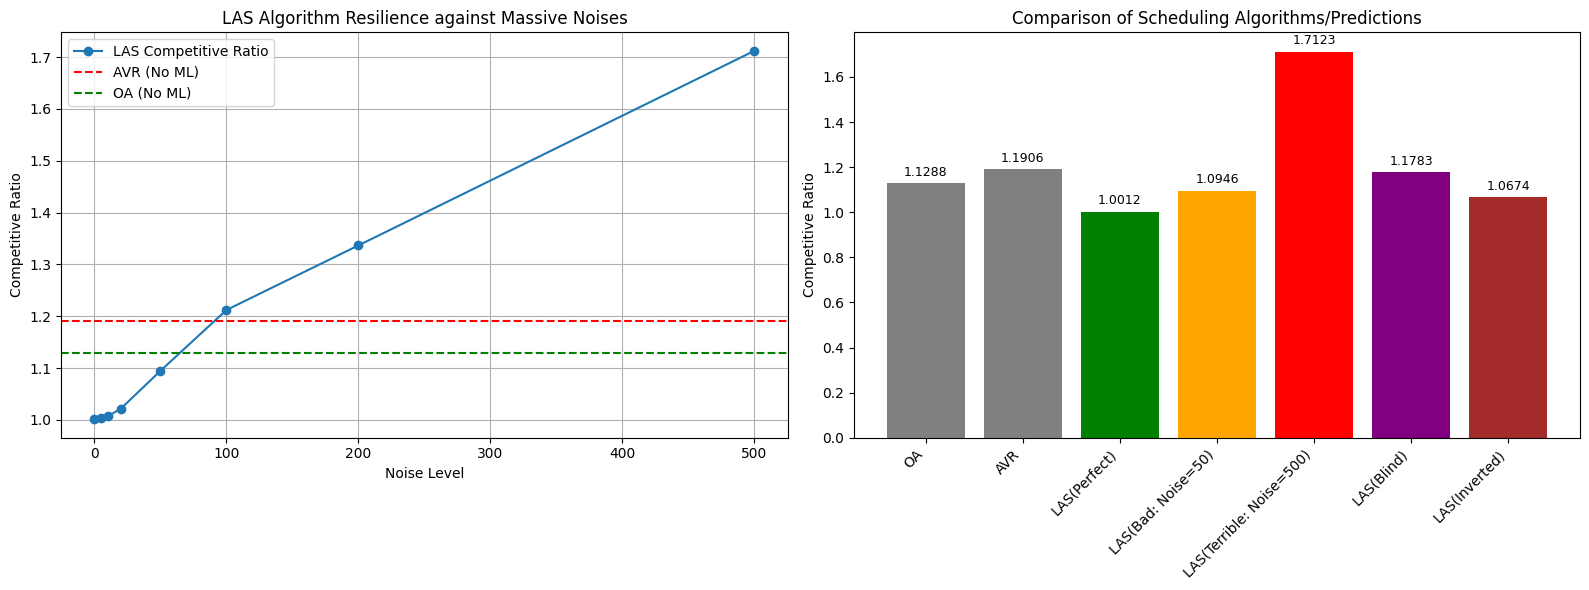

In [29]:
las_noises_ratios = []
noise_levels = [0, 5, 10, 20, 50, 100, 200, 500]
for nl in noise_levels:
    if nl == 0:
        J_pred = job_instance_creation(w_true, D)
    else:
        J_pred, _ = generate_massive_noises(w_true, D, nl)
    r = LAS_energy_ratio(J_true, J_pred, epsilon, alpha, dt)
    las_noises_ratios.append(r)

J_pred_blind, _ = generate_blind_prediction(num_jobs, D)
las_blind = LAS_energy_ratio(J_true, J_pred_blind, epsilon, alpha, dt)

J_pred_inv, _ = generate_inverted_prediction(w_true, D)
las_inv = LAS_energy_ratio(J_true, J_pred_inv, epsilon, alpha, dt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(noise_levels, las_noises_ratios, marker="o", label="LAS Competitive Ratio")
ax1.axhline(y=AVR, color="r", linestyle="--", label="AVR (No ML)")
ax1.axhline(y=OA, color="g", linestyle="--", label="OA (No ML)")
ax1.set_xlabel("Noise Level")
ax1.set_ylabel("Competitive Ratio")
ax1.set_title("LAS Algorithm Resilience against Massive Noises")
ax1.legend()
ax1.grid(True)

labels = ["OA", "AVR", "LAS(Perfect)", "LAS(Bad: Noise=50)", "LAS(Terrible: Noise=500)", "LAS(Blind)", "LAS(Inverted)"]
values = [OA, AVR, las_noises_ratios[0], las_noises_ratios[noise_levels.index(50)], las_noises_ratios[noise_levels.index(500)], las_blind, las_inv]

bars = ax2.bar(labels, values, color=["gray", "gray", "green", "orange", "red", "purple", "brown"])
ax2.set_ylabel("Competitive Ratio")
ax2.set_title("Comparison of Scheduling Algorithms/Predictions")
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
